# *Wstęp do uczenia maszynowego* 2026 - projekt 1
**Author: Denys Yakovliev**  


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!gdown --id 1UXzPHp23UmFZqMYtzUeZ_IX-_XWNzX5t
!unzip -n baza.zip
# drive.flush_and_unmount()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1UXzPHp23UmFZqMYtzUeZ_IX-_XWNzX5t
To: /content/baza.zip
100% 3.07M/3.07M [00:00<00:00, 47.2MB/s]
Archive:  baza.zip


In [2]:
!pip install "numpy<2" scikit-learn-extra
import os
import glob
from PIL import Image
import colorsys
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
import warnings
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Task 1: Dataset preparation

In [3]:
# Define the base directory where images are unzipped
IMAGE_DIR = 'kot-kwiat'

# Get a list of all image file paths
image_files = glob.glob(os.path.join(IMAGE_DIR, '*.png'))

# Initialize lists to store data for DataFrame (a) and (b)
all_pixel_data = [] # For df_pixels

#### Processing Images for DataFrame (a) - `df_pixels`

This section iterates through all images, extracts pixel data (RGB and HSL), and stores it along with pixel coordinates and image metadata. This will form the basis for `df_pixels`.

In [4]:
unique_color_counts = {'kotek': {}, 'kwiatek': {}} # For df_unique_colors intermediate counting

for img_path in image_files:
    img_name = os.path.basename(img_path)
    img_type = 'kotek' if 'kotek' in img_name else 'kwiatek'

    try:
        img = Image.open(img_path).convert('RGB')
        pixels = img.load()
        width, height = img.size

        for y in range(height):
            for x in range(width):
                r, g, b = pixels[x, y]

                # Convert RGB to HSL (colorsys expects 0-1 range for HSL)
                h, s, l = colorsys.rgb_to_hls(r/255.0, g/255.0, b/255.0)

                # Store data for df_pixels
                all_pixel_data.append({
                    'image_name': img_name,
                    'image_type': img_type,
                    'x': x,
                    'y': y,
                    'r': r, 'g': g, 'b': b,
                    'h': h, 's': s, 'l': l
                })

                # For df_unique_colors, we need to count unique colors per image type
                rgb_tuple = (r, g, b)
                unique_color_counts[img_type][rgb_tuple] = unique_color_counts[img_type].get(rgb_tuple, 0) + 1

    except Exception as e:
        print(f"Error processing {img_name}: {e}")

# Create DataFrame (a)
df_pixels = pd.DataFrame(all_pixel_data)
print("DataFrame (a) - df_pixels head:")
display(df_pixels.head())
print(f"df_pixels shape: {df_pixels.shape}")

DataFrame (a) - df_pixels head:


,image_name,image_type,x,y,r,g,b,h,s,l
0,kotek-49.png,kotek,0,0,120,112,57,0.145503,0.347059,0.355932
1,kotek-49.png,kotek,1,0,226,199,125,0.122112,0.688235,0.635220
2,kotek-49.png,kotek,2,0,237,222,184,0.119497,0.825490,0.595506
3,kotek-49.png,kotek,3,0,214,195,150,0.117187,0.713725,0.438356
4,kotek-49.png,kotek,4,0,117,118,59,0.169492,0.347059,0.333333


df_pixels shape: (1320000, 10)


#### Processing Images for DataFrame (b) - `df_unique_colors`

This section builds `df_unique_colors` from the collected unique color counts, adding the binary dominance and HSL flags as specified in the task.

In [5]:
# Prepare data for DataFrame (b)
unique_color_rows = []

all_unique_rgb_colors = set(unique_color_counts.get('kotek', {}).keys()).union(set(unique_color_counts.get('kwiatek', {}).keys()))

for rgb_color in all_unique_rgb_colors:
    r, g, b = rgb_color

    # Convert RGB to HSL for 'cold' and 'saturated' checks
    h, s, l = colorsys.rgb_to_hls(r/255.0, g/255.0, b/255.0)

    # Binary dominance flags for RGB
    max_rgb = max(r, g, b)
    dom_r = 1 if r == max_rgb else 0
    dom_g = 1 if g == max_rgb else 0
    dom_b = 1 if b == max_rgb else 0

    # Binary flags for HSL
    # HSL h is in [0, 1], so convert to degrees [0, 360]
    h_deg = h * 360
    s_percent = s * 100

    czy_zimny = 1 if (h_deg >= 180 and h_deg <= 270) else 0
    czy_nasycony = 1 if s_percent > 70 else 0

    unique_color_rows.append({
        'r': r, 'g': g, 'b': b,
        'h': h, 's': s, 'l': l,
        'count_kotek': unique_color_counts.get('kotek', {}).get(rgb_color, 0),
        'count_kwiatek': unique_color_counts.get('kwiatek', {}).get(rgb_color, 0),
        'dom_r': dom_r,
        'dom_g': dom_g,
        'dom_b': dom_b,
        'czy_zimny': czy_zimny,
        'czy_nasycony': czy_nasycony
    })

# Create DataFrame (b)
df_unique_colors = pd.DataFrame(unique_color_rows)
print("\nDataFrame (b) - df_unique_colors head:")
display(df_unique_colors.head())
print(f"df_unique_colors shape: {df_unique_colors.shape}")


DataFrame (b) - df_unique_colors head:


,r,g,b,h,s,l,count_kotek,count_kwiatek,dom_r,dom_g,dom_b,czy_zimny,czy_nasycony
0,123,177,108,0.297101,0.558824,0.306667,0,1,0,1,0,0,0
1,215,220,221,0.527778,0.854902,0.081081,1,0,0,0,1,1,1
2,95,73,60,0.061905,0.303922,0.225806,2,0,1,0,0,0,0
3,96,90,81,0.100000,0.347059,0.084746,1,0,1,0,0,0,0
4,199,234,153,0.238683,0.758824,0.658537,1,0,0,1,0,0,1


df_unique_colors shape: (848248, 13)


#### Verification Step

As per the task, we need to verify the correctness by displaying an original cat image and its reconstruction from the generated DataFrame `df_pixels`.

Selected cat image number for verification: kotek-38.png

Original Image:


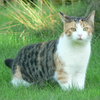


Reconstructed Image from DataFrame:


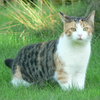

In [6]:
index_num = 477976
image_num_for_verification = (index_num % 100) // 2
print(f"Selected cat image number for verification: kotek-{image_num_for_verification}.png")

target_image_name = f'kotek-{image_num_for_verification}.png'

# Display original image
original_img_path = os.path.join(IMAGE_DIR, target_image_name)
if os.path.exists(original_img_path):
    print("\nOriginal Image:")
    display(Image.open(original_img_path))
else:
    print(f"Original image {target_image_name} not found at {original_img_path}")

# Reconstruct image from df_pixels
image_pixels_df = df_pixels[df_pixels['image_name'] == target_image_name]

if not image_pixels_df.empty:
    # Assuming images are 100x100 pixels based on task description
    width, height = 100, 100
    reconstructed_img = Image.new('RGB', (width, height))

    for index, row in image_pixels_df.iterrows():
        reconstructed_img.putpixel((row['x'], row['y']), (row['r'], row['g'], row['b']))

    print("\nReconstructed Image from DataFrame:")
    display(reconstructed_img)
else:
    print(f"No pixel data found for image {target_image_name} in df_pixels.")


df_pixels contains every pixel in the data provided, represented as (columns:) its r,g,b, h,s,l values, x,y coordinates, its filename and 'kotek' or 'kwiatek' class belonging.

df_unique_colors contains every unique color in the data provided, represented as (columns:) its r,g,b, h,s,l values, number of 'kotek' and 'kwiatek' pixels it appears on, coldness (czy_zimny) and saturation (czy_nasycony) based on its HSL and its color dominance: Red, Green or Blue.

### Task 2: Data Summarization and Exploration

#### 2.1: Calculate unique colors per image and other statistics

In [7]:
# Calculate the number of unique colors for each image
unique_colors_per_image = df_pixels.groupby(['image_name', 'image_type'])[['r', 'g', 'b']].apply(lambda x: len(x.drop_duplicates())).reset_index(name='unique_color_count')

# Separate for kotek and kwiatek
unique_colors_kotek = unique_colors_per_image[unique_colors_per_image['image_type'] == 'kotek']
unique_colors_kwiatek = unique_colors_per_image[unique_colors_per_image['image_type'] == 'kwiatek']

print("\n--- Unique Colors per Image Statistics ---")

# General statistics
print("Overall Unique Colors per Image:")
print(f"  Min: {unique_colors_per_image['unique_color_count'].min()}")
print(f"  Max: {unique_colors_per_image['unique_color_count'].max()}")
print(f"  Mean: {unique_colors_per_image['unique_color_count'].mean():.2f}")
print(f"  Median: {unique_colors_per_image['unique_color_count'].median()}")
print(f"  Std Dev: {unique_colors_per_image['unique_color_count'].std():.2f}")

# Statistics for 'kotek' images
print("\nUnique Colors per 'kotek' Image:")
print(f"  Min: {unique_colors_kotek['unique_color_count'].min()}")
print(f"  Max: {unique_colors_kotek['unique_color_count'].max()}")
print(f"  Mean: {unique_colors_kotek['unique_color_count'].mean():.2f}")
print(f"  Median: {unique_colors_kotek['unique_color_count'].median()}")
print(f"  Std Dev: {unique_colors_kotek['unique_color_count'].std():.2f}")

# Statistics for 'kwiatek' images
print("\nUnique Colors per 'kwiatek' Image:")
print(f"  Min: {unique_colors_kwiatek['unique_color_count'].min()}")
print(f"  Max: {unique_colors_kwiatek['unique_color_count'].max()}")
print(f"  Mean: {unique_colors_kwiatek['unique_color_count'].mean():.2f}")
print(f"  Median: {unique_colors_kwiatek['unique_color_count'].median()}")
print(f"  Std Dev: {unique_colors_kwiatek['unique_color_count'].std():.2f}")

# Number of cat and flower images
num_kotek_images = len(unique_colors_kotek)
num_kwiatek_images = len(unique_colors_kwiatek)
print(f"\nNumber of 'kotek' images: {num_kotek_images}")
print(f"Number of 'kwiatek' images: {num_kwiatek_images}")
print(f"Total images: {num_kotek_images + num_kwiatek_images}")


--- Unique Colors per Image Statistics ---
Overall Unique Colors per Image:
  Min: 4538
  Max: 9911
  Mean: 8649.39
  Median: 9072.5
  Std Dev: 1163.40

Unique Colors per 'kotek' Image:
  Min: 7339
  Max: 9911
  Mean: 9207.02
  Median: 9387.0
  Std Dev: 575.12

Unique Colors per 'kwiatek' Image:
  Min: 4538
  Max: 9881
  Mean: 8251.09
  Median: 8768.0
  Std Dev: 1308.53

Number of 'kotek' images: 55
Number of 'kwiatek' images: 77
Total images: 132


As you can see, images contain roughly 9000 colors, with median deviating ~300 colors towards more unique colors for 'kotek' type and 300 towards less for 'kwiatek' type. The mean is less than the median, which implies left-skewness of the dataset. 'kwiatek' can have much less colors, as evidenced by its Min value. Standard deviation is ~2.5 times greater for 'kwiatek' which corresponds to ~2 times greater min-max interval.

#### 2.2: Most Frequent Colors, Brightness, and Saturation Analysis

In [8]:
# Identify the top 5 most frequent colors for 'kotek' images
top_5_kotek_colors = df_unique_colors.nlargest(5, 'count_kotek')[['r', 'g', 'b', 'count_kotek']]
print("\nTop 5 Most Frequent Colors in 'kotek' Images:")
display(top_5_kotek_colors)

# Identify the top 5 most frequent colors for 'kwiatek' images
top_5_kwiatek_colors = df_unique_colors.nlargest(5, 'count_kwiatek')[['r', 'g', 'b', 'count_kwiatek']]
print("\nTop 5 Most Frequent Colors in 'kwiatek' Images:")
display(top_5_kwiatek_colors)

# --- Brightness (L) and Saturation (S) Analysis ---

# Filter df_pixels for 'kotek' and 'kwiatek'
pixels_kotek = df_pixels[df_pixels['image_type'] == 'kotek']
pixels_kwiatek = df_pixels[df_pixels['image_type'] == 'kwiatek']

print("\n--- Brightness (L) and Saturation (S) Statistics ---")

# Statistics for 'kotek' images
print("\n'kotek' Images Lightness and Saturation:")
print(f"  Lightness (L) - Min: {pixels_kotek['l'].min():.2f}, Max: {pixels_kotek['l'].max():.2f}, Mean: {pixels_kotek['l'].mean():.2f}, Median: {pixels_kotek['l'].median():.2f}, Std Dev: {pixels_kotek['l'].std():.2f}")
print(f"  Saturation (S) - Min: {pixels_kotek['s'].min():.2f}, Max: {pixels_kotek['s'].max():.2f}, Mean: {pixels_kotek['s'].mean():.2f}, Median: {pixels_kotek['s'].median():.2f}, Std Dev: {pixels_kotek['s'].std():.2f}")

# Statistics for 'kwiatek' images
print("\n'kwiatek' Images Lightness and Saturation:")
print(f"  Lightness (L) - Min: {pixels_kwiatek['l'].min():.2f}, Max: {pixels_kwiatek['l'].max():.2f}, Mean: {pixels_kwiatek['l'].mean():.2f}, Median: {pixels_kwiatek['l'].median():.2f}, Std Dev: {pixels_kwiatek['l'].std():.2f}")
print(f"  Saturation (S) - Min: {pixels_kwiatek['s'].min():.2f}, Max: {pixels_kwiatek['s'].max():.2f}, Mean: {pixels_kwiatek['s'].mean():.2f}, Median: {pixels_kwiatek['s'].median():.2f}, Std Dev: {pixels_kwiatek['s'].std():.2f}")


Top 5 Most Frequent Colors in 'kotek' Images:


,r,g,b,count_kotek
123459,255,255,255,538
116572,254,254,254,308
110099,0,0,0,240
417762,253,253,253,156
618260,246,245,241,78



Top 5 Most Frequent Colors in 'kwiatek' Images:


,r,g,b,count_kwiatek
110099,0,0,0,4462
123459,255,255,255,1331
388282,1,1,1,894
82720,2,2,2,489
629356,3,3,3,452



--- Brightness (L) and Saturation (S) Statistics ---

'kotek' Images Lightness and Saturation:
  Lightness (L) - Min: 0.00, Max: 1.00, Mean: 0.32, Median: 0.28, Std Dev: 0.22
  Saturation (S) - Min: 0.00, Max: 1.00, Mean: 0.42, Median: 0.40, Std Dev: 0.21

'kwiatek' Images Lightness and Saturation:
  Lightness (L) - Min: 0.00, Max: 1.00, Mean: 0.47, Median: 0.40, Std Dev: 0.30
  Saturation (S) - Min: 0.00, Max: 1.00, Mean: 0.37, Median: 0.35, Std Dev: 0.23


For both classes Lightness and Saturation min-max values are the greatest they can be, 0 and 1 accordingly; also, the distributions are right-skewed, meaning larger saturation and lightness values are less common. Standard deviations are greater for 'kwiatek' images saturation and lightness, meaning they are less uniform in that respect. The greatest difference, however, is in the lightness mean, for 'kwiatek' it reaches 0.47, compared to 0.32 for 'kotek', which might be a great single predictor variable.  

#### 2.3: Visualizations

Let's visualize the data distributions as requested.

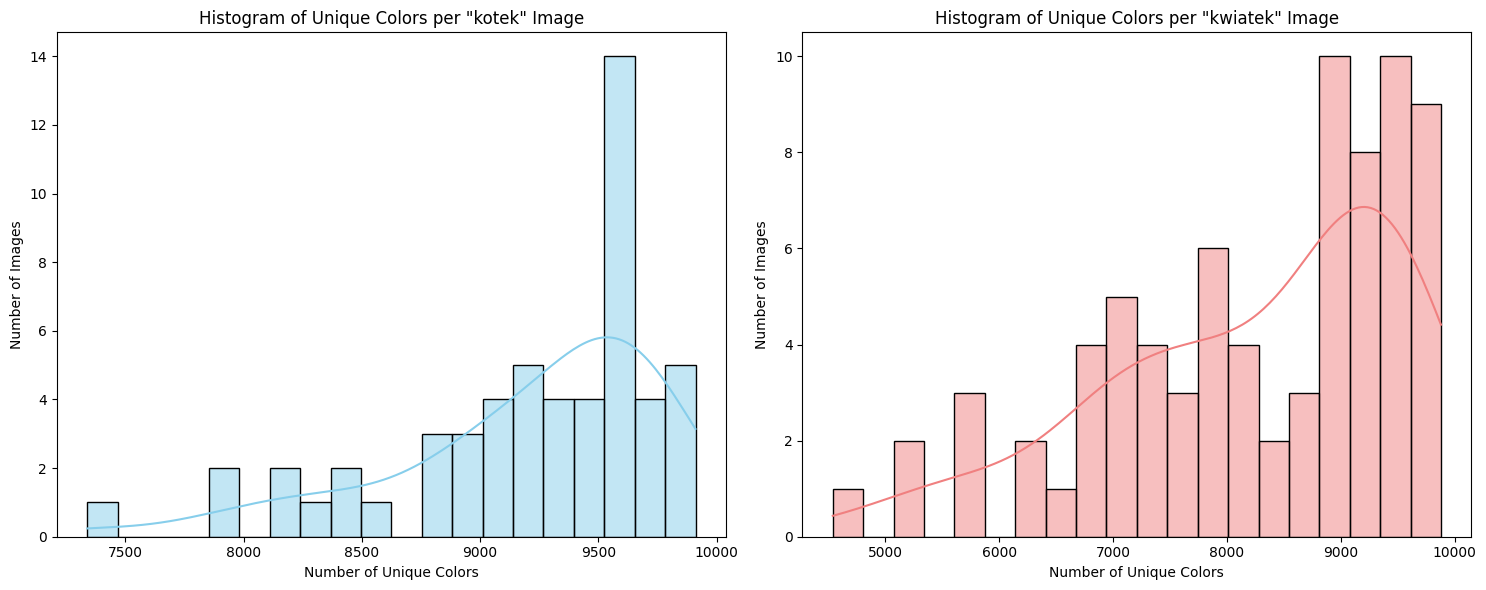


Comment: These histograms show the distribution of unique colors found in each 'kotek' and 'kwiatek' image. 
We can observe a significant difference in color complexity between the two image types. 
For instance, the high peak in one basket and uniform distribution in its vicinity characterizes the low standard deviation of 'kotek' unique colors we've seen earlier. The saircase-like distribution in the 'kwiatek' histogram might indicate lower need for coloration in that category of images, as, intuitively, flowers are usually colored uniformly.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of unique colors for 'kotek' and 'kwiatek'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(unique_colors_kotek['unique_color_count'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Unique Colors per "kotek" Image')
axes[0].set_xlabel('Number of Unique Colors')
axes[0].set_ylabel('Number of Images')

sns.histplot(unique_colors_kwiatek['unique_color_count'], bins=20, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Histogram of Unique Colors per "kwiatek" Image')
axes[1].set_xlabel('Number of Unique Colors')
axes[1].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

# Comment for the histogram:
print("\nComment: These histograms show the distribution of unique colors found in each 'kotek' and 'kwiatek' \
image. \nWe can observe a significant difference in color complexity between the two image types. \
\nFor instance, the high peak in one basket and uniform distribution in its vicinity characterizes the low \
\nstandard deviation of 'kotek' unique colors we've seen earlier. The staircase-like distribution in the \
\n'kwiatek' histogram might indicate lower need for coloration in that category of images, as, intuitively, \
\nflower petals are usually colored more uniformly than cats' fur.")

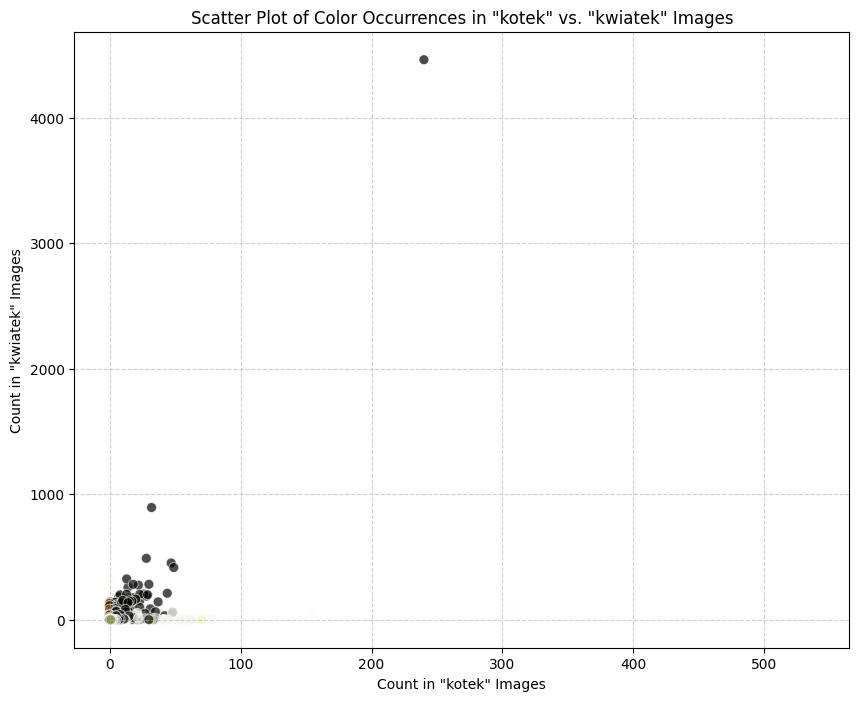


Comment: This scatter plot visualizes the co-occurrence of unique colors in 'kotek' and 'kwiatek' images. 
Each point represents a unique color, and its position indicates how frequently it appears in cat images 
(x-axis) versus flower images (y-axis). The color of the point itself is the actual RGB color. 
This helps in identifying colors that are more specific to one category, or those that are common to both. 
For example, points along the x-axis (low y-value) are more prevalent in cat images, 
while points along the y-axis (low x-value) are more prevalent in flower images. 
Points along the diagonal appear roughly equally in both.


In [10]:
# Scatter plot for color occurrences, colored by RGB

# Convert RGB values to a format suitable for matplotlib colors (0-1 range)
df_unique_colors['color_rgb_norm'] = df_unique_colors.apply(lambda row: (row['r']/255.0, row['g']/255.0, row['b']/255.0), axis=1)

fig = plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='count_kotek',
    y='count_kwiatek',
    data=df_unique_colors,
    c=list(df_unique_colors['color_rgb_norm']),
    s=50, # size of points
    alpha=0.7 # transparency
)

plt.title('Scatter Plot of Color Occurrences in "kotek" vs. "kwiatek" Images')
plt.xlabel('Count in "kotek" Images')
plt.ylabel('Count in "kwiatek" Images')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Comment for the scatter plot:
print("\nComment: This scatter plot visualizes the co-occurrence of unique colors in 'kotek' and 'kwiatek' images. \
\nEach point represents a unique color, and its position indicates how frequently it appears in cat images \
\n(x-axis) versus flower images (y-axis). The color of the point itself is the actual RGB color. \
\nThis helps in identifying colors that are more specific to one category, or those that are common to both. \
\nFor example, points along the x-axis (low y-value) are more prevalent in cat images, \
\nwhile points along the y-axis (low x-value) are more prevalent in flower images. \
\nPoints along the diagonal appear roughly equally in both.")

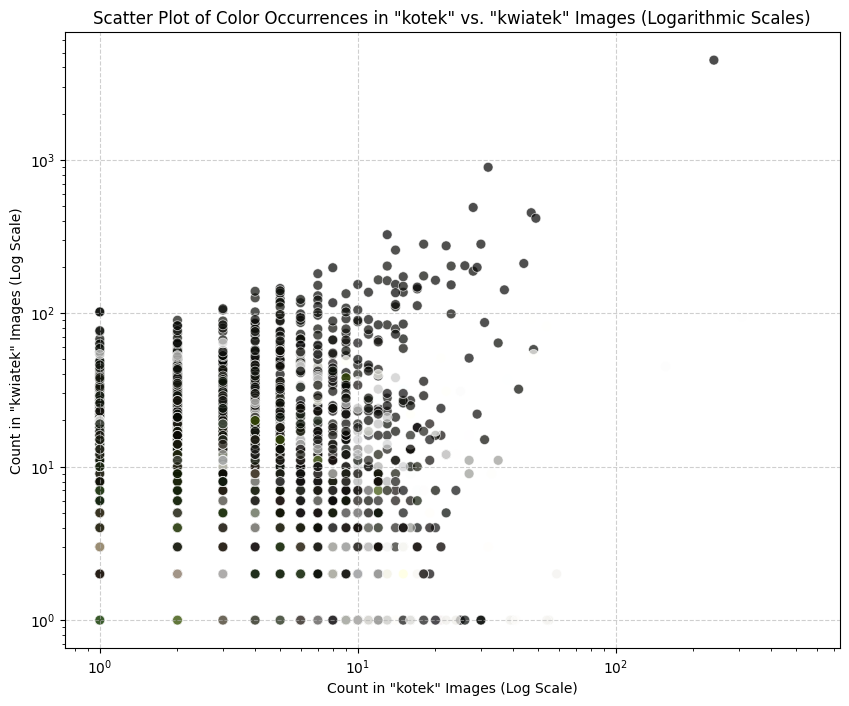


Comment: This scatter plot uses logarithmic scales on both axes to better visualize the distribution of unique colors, especially those with lower occurrences. It helps to reveal patterns that might be obscured when using linear scales, as it spreads out compressed data points in the lower ranges.


In [11]:
# Scatter plot with Logarithmic Scales
fig = plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='count_kotek',
    y='count_kwiatek',
    data=df_unique_colors,
    c=list(df_unique_colors['color_rgb_norm']),
    s=50, # size of points
    alpha=0.7 # transparency
)

plt.xscale('log')
plt.yscale('log')

plt.title('Scatter Plot of Color Occurrences in "kotek" vs. "kwiatek" Images (Logarithmic Scales)')
plt.xlabel('Count in "kotek" Images (Log Scale)')
plt.ylabel('Count in "kwiatek" Images (Log Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Comment for the logarithmic scatter plot:
print("\nComment: This scatter plot uses logarithmic scales on both axes to better visualize the distribution \
\nof unique colors, especially those with lower occurrences. It helps to reveal patterns that might be \
\nobscured when using linear scales, as it spreads out compressed data points in the lower ranges.")

A lot of gray values indicate that colorful flowers have much more grayscale in common with cats, all the petal colors supposedly having 0 on the X-axis.

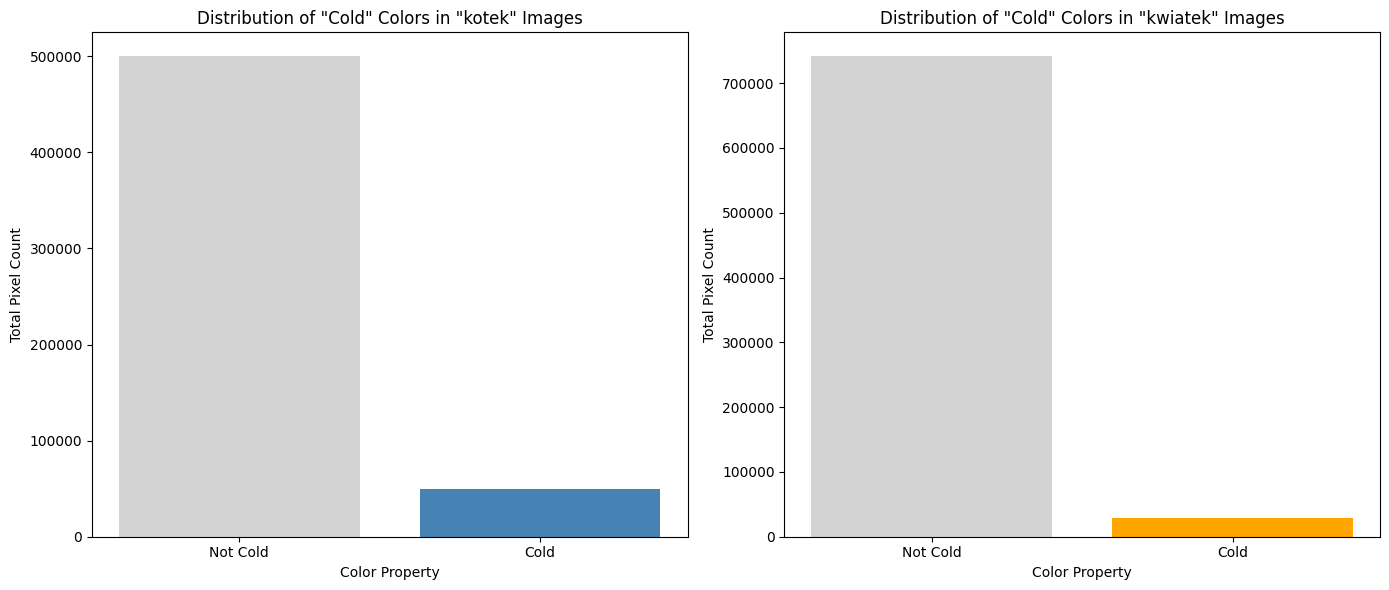


Comment: This stacked bar chart illustrates the distribution of 'cold' colors (based on HSL 'h' component) within the pixel data of 'kotek' and 'kwiatek' images. It allows us to compare whether one image type tends to have a higher proportion of 'cold' colors compared to the other. For instance, if 'kotek' images show a significantly larger 'Cold' bar, it suggests cats in the dataset frequently feature cooler hues.


In [12]:
# Stacked bar chart for a binary variable (e.g., 'czy_zimny')

# Aggregate counts for 'czy_zimny' by image type
zimny_counts = df_unique_colors.groupby('czy_zimny').agg(
    count_kotek=('count_kotek', 'sum'),
    count_kwiatek=('count_kwiatek', 'sum')
).reset_index()

# Rename 'czy_zimny' for better plot labels
zimny_counts['czy_zimny_label'] = zimny_counts['czy_zimny'].map({0: 'Not Cold', 1: 'Cold'})

# Prepare data for stacking
kotek_cold = zimny_counts[zimny_counts['czy_zimny'] == 1]['count_kotek'].iloc[0] if 1 in zimny_counts['czy_zimny'].values else 0
kotek_not_cold = zimny_counts[zimny_counts['czy_zimny'] == 0]['count_kotek'].iloc[0] if 0 in zimny_counts['czy_zimny'].values else 0

kwiatek_cold = zimny_counts[zimny_counts['czy_zimny'] == 1]['count_kwiatek'].iloc[0] if 1 in zimny_counts['czy_zimny'].values else 0
kwiatek_not_cold = zimny_counts[zimny_counts['czy_zimny'] == 0]['count_kwiatek'].iloc[0] if 0 in zimny_counts['czy_zimny'].values else 0


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for 'kotek'
axes[0].bar(['Not Cold', 'Cold'], [kotek_not_cold, kotek_cold], color=['lightgray', 'steelblue'])
axes[0].set_title('Distribution of "Cold" Colors in "kotek" Images')
axes[0].set_xlabel('Color Property')
axes[0].set_ylabel('Total Pixel Count')

# Plot for 'kwiatek'
axes[1].bar(['Not Cold', 'Cold'], [kwiatek_not_cold, kwiatek_cold], color=['lightgray', 'orange'])
axes[1].set_title('Distribution of "Cold" Colors in "kwiatek" Images')
axes[1].set_xlabel('Color Property')
axes[1].set_ylabel('Total Pixel Count')

plt.tight_layout()
plt.show()

# Comment for the stacked bar chart:
print("\nComment: This stacked bar chart illustrates the distribution of 'cold' colors (based on HSL 'h' \
component) \nwithin the pixel data of 'kotek' and 'kwiatek' images. It allows us to compare whether one image \
\ntype tends to have a higher proportion of 'cold' colors compared to the other. For instance, if 'kotek' \
\nimages show a significantly larger 'Cold' bar, which it does, it suggests cats in the dataset frequently \
\nfeature cooler hues.")

### Task 3: Color Palette Reduction using Clustering

#### 3.1: Variable Selection and Transformation for Clustering

According to the task description, the goal is to reduce the color palette. The available variables for clustering are RGB components (r, g, b) and HSL components (h, s, l) from `df_pixels`.

**Variable Selection:**
I choose to use the **HSL (Hue, Saturation, Lightness) components** for clustering. The reasoning is as follows:

*   **Perceptual Consistency:** The HSL model is closer to how humans perceive colors. Hue, Saturation, and Lightness are more intuitively separated than RGB components, which are often correlated. This allows for clustering that may better correspond to human perception of color similarity.
*   **Component Independence:** HSL naturally separates color attributes. For example, changing the lightness of a pixel in RGB changes all three R, G, B components, while in HSL it changes only one 'l' component, which can lead to more meaningful clusters.

**Transformation (Scaling):**
HSL components (h, s, l) are already normalized in the range of 0.0 to 1.0 (Hue is in [0, 1] representing an angle from 0 to 360 degrees, Saturation and Lightness are in [0, 1] representing percentage values). For this reason, **additional scaling is not necessary** at the initial stage, because distance-based clustering algorithms (such as k-means or k-medoids) will treat all three components on a similar scale of importance. However, if we notice that one component dominates distance calculations, we could consider weighting or scaling to a different scale (e.g. making each feature have a mean of 0 and a standard deviation of 1, giving every component equal weight in the distance metric), but for preliminary analysis and given the characteristics of HSL, it is not required.


#### 3.2: Applying Clustering Algorithms

We will run both K-Means and K-Medoids for $k \in \{5, 10, 20\}$ on the first image in the dataset. For each configuration, we perform 5 iterations using the specified seeds: `{1104, 12041, 130412, 140413, 150414}`.

Metrics used:
1. **Silhouette Score**: Higher is better (range -1 to 1).
2. **Caliński-Harabasz Index (CHI)**: Higher indicates better defined clusters.

In [13]:
# Suppress specific UserWarnings from K-Medoids about empty clusters
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn_extra')

SAMPLE_SIZE = 1000
metrics_results = []
k_values = [5, 10, 20]
seeds = [1104, 12041, 130412, 140413, 150414]

# Process all images
target_images = image_files

for target_img in target_images:
    img_name = os.path.basename(target_img)
    print(f"Processing image: {img_name}")

    # Load and prepare pixels
    img = Image.open(target_img).convert('RGB')
    pixels_raw = np.array(img).reshape(-1, 3)
    X_hsl_demo = pd.DataFrame([colorsys.rgb_to_hls(r/255.0, g/255.0, b/255.0) for r, g, b in pixels_raw], columns=['h', 's', 'l'])

    # Sample for silhouette scores
    X_sample_metrics = X_hsl_demo.sample(n=min(len(X_hsl_demo), SAMPLE_SIZE), random_state=42)

    for k in k_values:
        for i, seed in enumerate(seeds):
            # KMeans
            km = KMeans(n_clusters=k, n_init=1, init='random', random_state=seed)
            km_labels = km.fit_predict(X_hsl_demo)
            km_sil = silhouette_score(X_sample_metrics, km.predict(X_sample_metrics))
            km_chi = calinski_harabasz_score(X_hsl_demo, km_labels)

            metrics_results.append({'Image': img_name, 'Algorithm': 'K-Means', 'k': k, 'Iteration': i, 'Silhouette': km_sil, 'CHI': km_chi})

            # K-Medoids
            # Fit sample is smaller than for KMeans, for faster=> comparable fitting time
            kmed = KMedoids(n_clusters=k, random_state=seed, method='alternate', init='random', max_iter=100)
            kmed_fit_sample = X_hsl_demo.sample(n=min(len(X_hsl_demo), SAMPLE_SIZE), random_state=seed)
            kmed.fit(kmed_fit_sample)
            kmed_sil = silhouette_score(X_sample_metrics, kmed.predict(X_sample_metrics))
            kmed_chi = calinski_harabasz_score(X_hsl_demo, kmed.predict(X_hsl_demo))

            metrics_results.append({'Image': img_name, 'Algorithm': 'K-Medoids', 'k': k, 'Iteration': i, 'Silhouette': kmed_sil, 'CHI': kmed_chi})

df_metrics = pd.DataFrame(metrics_results)
print("\nClustering evaluation complete.")
display(df_metrics.groupby(['Algorithm', 'k'])[['Silhouette', 'CHI']].mean())

Processing image: kotek-49.png
Processing image: kwiatek-69.png
Processing image: kwiatek-68.png
Processing image: kotek-27.png
Processing image: kwiatek-63.png
Processing image: kotek-50.png
Processing image: kotek-0.png
Processing image: kotek-40.png
Processing image: kotek-43.png
Processing image: kwiatek-46.png
Processing image: kwiatek-24.png
Processing image: kwiatek-72.png
Processing image: kotek-10.png
Processing image: kwiatek-11.png
Processing image: kwiatek-39.png
Processing image: kwiatek-47.png
Processing image: kwiatek-35.png
Processing image: kwiatek-16.png
Processing image: kotek-21.png
Processing image: kwiatek-43.png
Processing image: kwiatek-29.png
Processing image: kotek-48.png
Processing image: kwiatek-51.png
Processing image: kwiatek-58.png
Processing image: kwiatek-2.png
Processing image: kotek-36.png
Processing image: kwiatek-21.png
Processing image: kwiatek-17.png
Processing image: kotek-5.png
Processing image: kotek-6.png
Processing image: kwiatek-18.png
Proce

Silhouette           CHI
Algorithm k                           
K-Means   5     0.423065  12960.406554
          10    0.365843  12157.126510
          20    0.331604  11276.511643
K-Medoids 5     0.360041  10077.580923
          10    0.309102   9345.801624
          20    0.271809   8269.455724

In [14]:
# Calculate means
summary_means = df_metrics.groupby(['Image', 'Algorithm', 'k'])[['Silhouette', 'CHI']].mean().reset_index()

csv_filename = 'mean_clustering_metrics.csv'
summary_means.to_csv(csv_filename, index=False)
!cp {csv_filename} /content/drive/MyDrive/

print(f"Success: Means saved to {csv_filename} and copied to Google Drive.")
display(summary_means.head())

Success: Means saved to mean_clustering_metrics.csv and copied to Google Drive.


,Image,Algorithm,k,Silhouette,CHI
0,kotek-0.png,K-Means,5,0.330700,5137.538290
1,kotek-0.png,K-Means,10,0.288317,4621.784583
2,kotek-0.png,K-Means,20,0.274827,4034.391815
3,kotek-0.png,K-Medoids,5,0.287522,4592.585868
4,kotek-0.png,K-Medoids,10,0.261232,3863.015932


#### 3.3: Visualization of Clustering Quality

The following violin plots show the distribution of scores across different $k$ values and iterations for both algorithms.

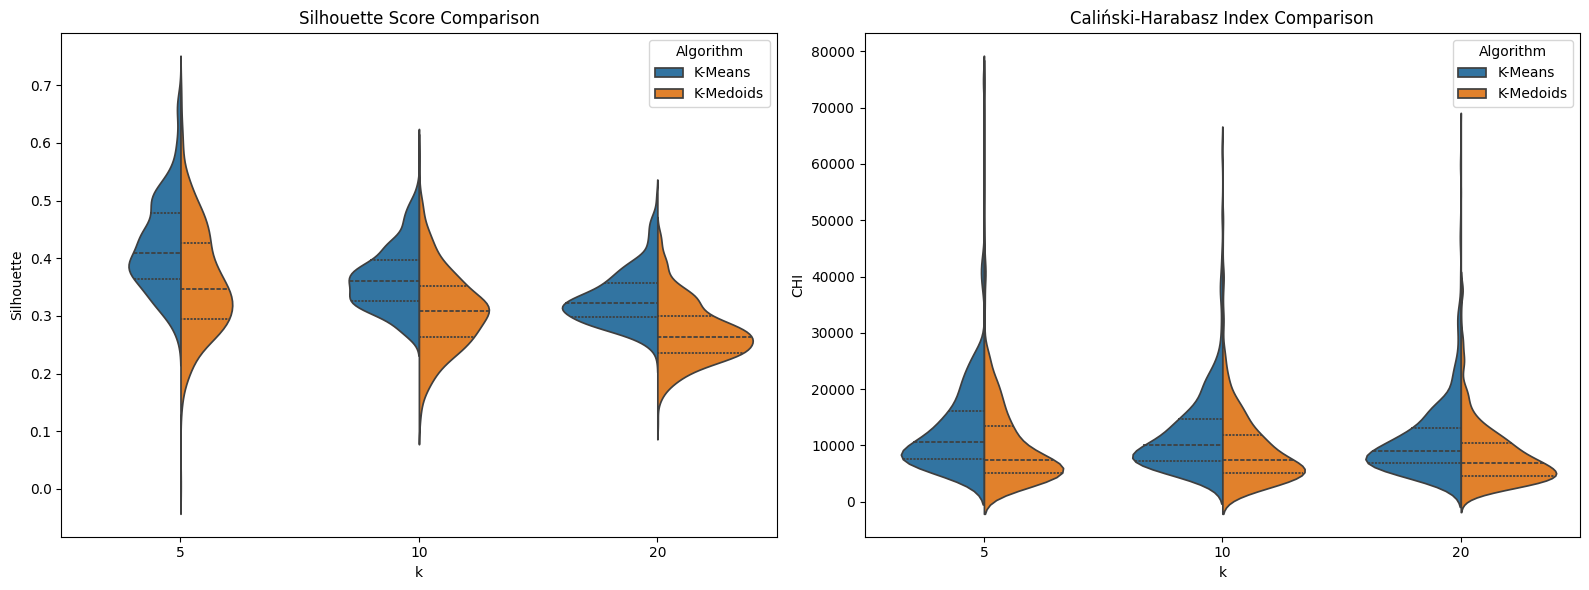

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(x='k', y='Silhouette', hue='Algorithm', data=df_metrics, ax=axes[0], split=True, inner="quart")
axes[0].set_title('Silhouette Score Comparison')

sns.violinplot(x='k', y='CHI', hue='Algorithm', data=df_metrics, ax=axes[1], split=True, inner="quart")
axes[1].set_title('Caliński-Harabasz Index Comparison')

plt.tight_layout()
plt.show()

Based on both violin plots, K-Means proves superior in this case, which is probably due to the smaller training set. Determining the optimal value of the hyperparameter K is visually easier using the silhouette score plot. The determined best k is 5 since it has better quartiles across every silhouette subplot, suggesting that while more clusters capture more detail, the separation between clusters is most distinct at smaller palettes.

Consistency: The tight distribution in the violin plots for K-Means suggests it is more robust to random initialization for this specific color-reduction task compared to K-Medoids.



#### 3.4: Color Palette Reduction Implementation

In this step, we apply the chosen algorithm (K-Means) with the selected $k$ to transform the images. Each pixel's original color is replaced by the RGB values of its assigned cluster centroid.

Original vs Reduced (k=5) for kotek-49.png:


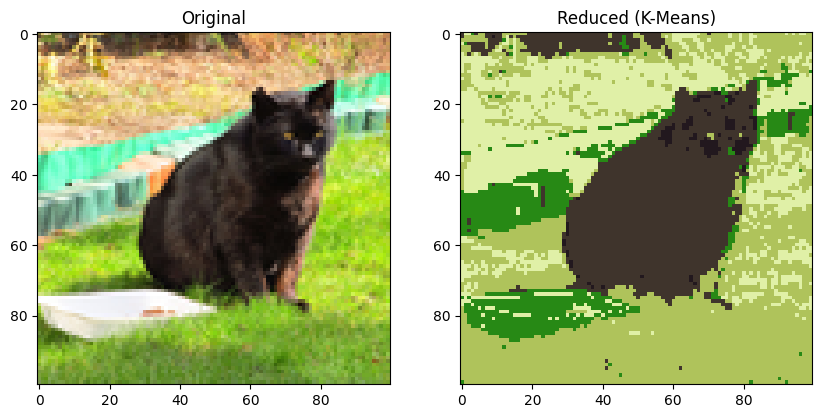

In [16]:
def reduce_color_palette(img_path, k=5, seed=1104):
    # Load image and convert to HSL
    img = Image.open(img_path).convert('RGB')
    pixels_raw = np.array(img).reshape(-1, 3)
    X_hsl = np.array([colorsys.rgb_to_hls(r/255.0, g/255.0, b/255.0) for r, g, b in pixels_raw])

    # Apply K-Means
    km = KMeans(n_clusters=k, n_init=1, random_state=seed)
    labels = km.fit_predict(X_hsl)

    # Convert cluster centers back to RGB [0, 255]
    centers_hsl = km.cluster_centers_
    centers_rgb = np.array([colorsys.hls_to_rgb(h, l, s) for h, s, l in centers_hsl]) * 255

    # Map labels to RGB centers
    reduced_pixels = centers_rgb[labels].astype(np.uint8)
    reduced_img = reduced_pixels.reshape(100, 100, 3)

    return Image.fromarray(reduced_img)

# Example transformation of the first image
example_path = image_files[0]
reduced_example = reduce_color_palette(example_path, k=5)

print(f"Original vs Reduced (k=5) for {os.path.basename(example_path)}:")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open(example_path))
axes[0].set_title('Original')
axes[1].imshow(reduced_example)
axes[1].set_title('Reduced (K-Means)')
plt.show()

#### 3.5 Comparison of K-Means vs K-Medoids for Random Images

Following the project requirements, we select 5 random images and compare the original with the reconstructions from both algorithms.

**Justification of Algorithm Choice:**
We choose **K-Means** for the final reduction. The evaluation metrics (Silhouette Score and CHI) shown in the violin plots indicate that K-Means consistently achieves higher values across different images and k-values. This suggests that K-Means creates more cohesive and well-separated color palettes compared to K-Medoids in this specific HSL feature space.

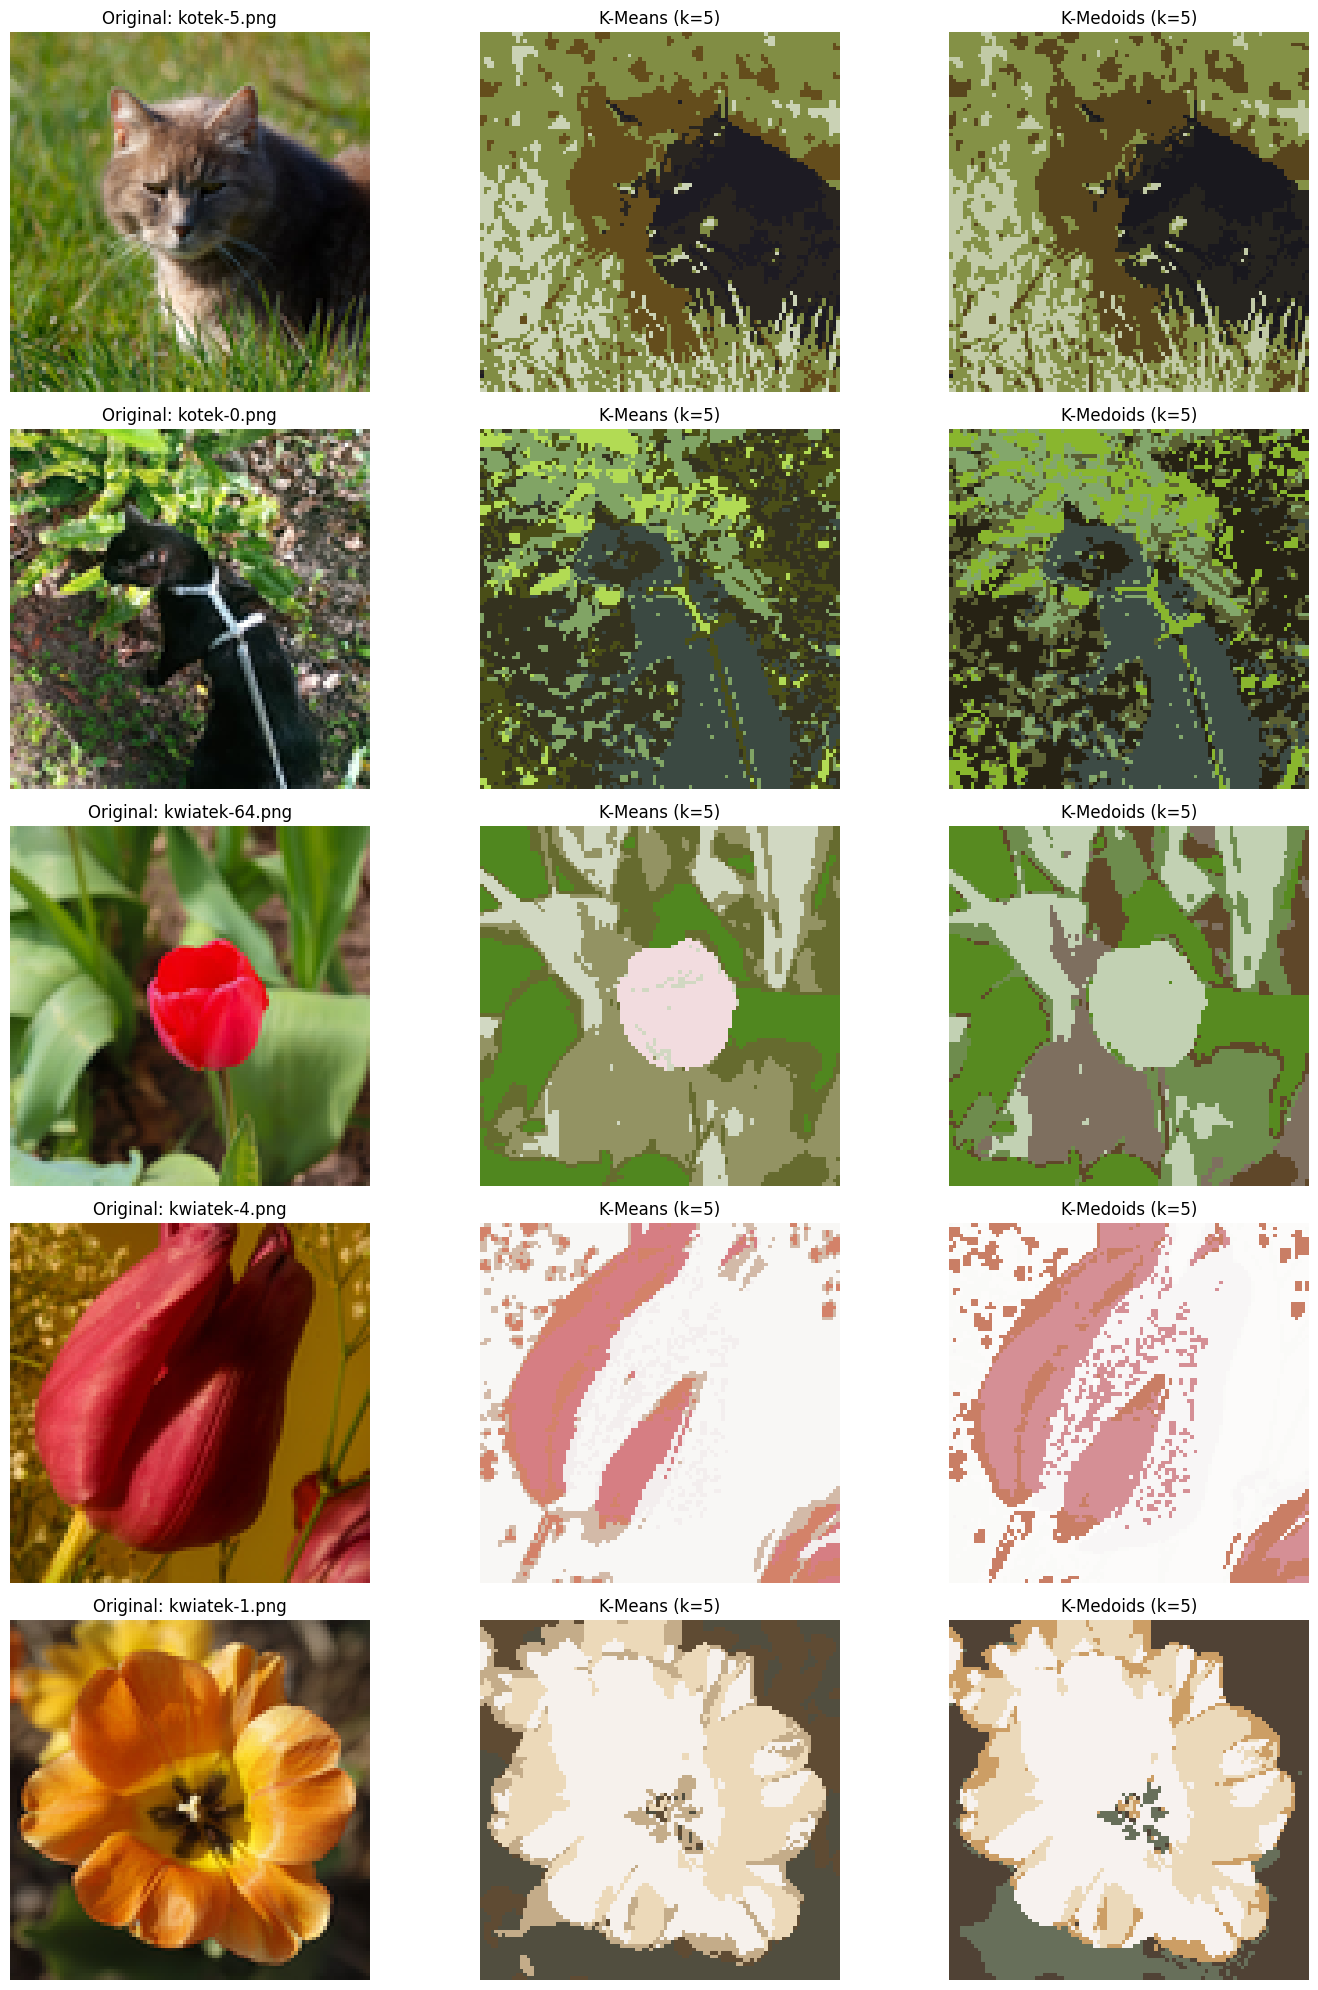

In [17]:
import random

# Set seed for reproducibility of random selection
random.seed(42)
selected_paths = random.sample(image_files, 5)

# Compare for a fixed k (e.g., k=5) to show the difference between algorithms
K_VAL = 5
fig, axes = plt.subplots(5, 3, figsize=(15, 20))

for idx, img_path in enumerate(selected_paths):
    img_name = os.path.basename(img_path)
    img_raw = Image.open(img_path).convert('RGB')
    pixels = np.array(img_raw).reshape(-1, 3)
    X_hsl = np.array([colorsys.rgb_to_hls(r/255.0, g/255.0, b/255.0) for r, g, b in pixels])

    # 1. Original
    axes[idx, 0].imshow(img_raw)
    axes[idx, 0].set_title(f"Original: {img_name}")
    axes[idx, 0].axis('off')

    # 2. K-Means Reconstruction
    km = KMeans(n_clusters=K_VAL, n_init=1, random_state=1104)
    km_labels = km.fit_predict(X_hsl)
    km_palette = np.array([colorsys.hls_to_rgb(h, l, s) for h, s, l in km.cluster_centers_]) * 255
    km_img = km_palette[km_labels].reshape(100, 100, 3).astype(np.uint8)
    axes[idx, 1].imshow(km_img)
    axes[idx, 1].set_title(f"K-Means (k={K_VAL})")
    axes[idx, 1].axis('off')

    # 3. K-Medoids Reconstruction
    kmed = KMedoids(n_clusters=K_VAL, random_state=1104, method='alternate')
    # K-Medoids is slow on full image, so we fit on a sample but predict on all
    X_sample_kmed = X_hsl[np.random.choice(len(X_hsl), 1000, replace=False)]
    kmed.fit(X_sample_kmed)
    kmed_labels = kmed.predict(X_hsl)
    kmed_palette = np.array([colorsys.hls_to_rgb(h, l, s) for h, s, l in kmed.cluster_centers_]) * 255
    kmed_img = kmed_palette[kmed_labels].reshape(100, 100, 3).astype(np.uint8)
    axes[idx, 2].imshow(kmed_img)
    axes[idx, 2].set_title(f"K-Medoids (k={K_VAL})")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

### Task 4: Compression Gain Analysis and Regression Modeling

In this section, we save the reduced images (using K-Means and $k=5$), calculate the compression gain, and build a regression model.

In [18]:
# Create directory for reduced images
REDUCED_DIR = 'reduced_images'
os.makedirs(REDUCED_DIR, exist_ok=True)

compression_data = []

for img_path in image_files:
    img_name = os.path.basename(img_path)

    # 1. Save reduced image
    reduced_img = reduce_color_palette(img_path, k=5)
    save_path = os.path.join(REDUCED_DIR, img_name)
    reduced_img.save(save_path, format='PNG')

    # 2. Calculate sizes in KB
    size_orig = os.path.getsize(img_path) / 1024
    size_red = os.path.getsize(save_path) / 1024

    # 3. Calculate compression gain
    gain = ((size_orig - size_red) / size_orig) * 100

    # Get unique color count from previous Task 2 results
    unique_colors = unique_colors_per_image[unique_colors_per_image['image_name'] == img_name]['unique_color_count'].values[0]

    compression_data.append({
        'image_name': img_name,
        'unique_colors': unique_colors,
        'gain': gain
    })

df_compression = pd.DataFrame(compression_data)
display(df_compression.head())

,image_name,unique_colors,gain
0,kotek-49.png,9311,91.965129
1,kwiatek-69.png,7448,82.712530
2,kwiatek-68.png,8986,88.682479
3,kotek-27.png,9846,78.558321
4,kwiatek-63.png,9417,85.156649


Evaluating various functional forms for Regression:
Linear: Gain ~ UniqueColors - R2 Score: 0.0011
Quadratic: Gain ~ UniqueColors^2 - R2 Score: 0.0000
Logarithmic: Gain ~ log(UniqueColors) - R2 Score: 0.0039
Reciprocal: Gain ~ 1/UniqueColors - R2 Score: 0.0085
Exponential: log(Gain) ~ UniqueColors - R2 Score: 0.0010
Power Law: log(Gain) ~ log(UniqueColors) - R2 Score: 0.0039


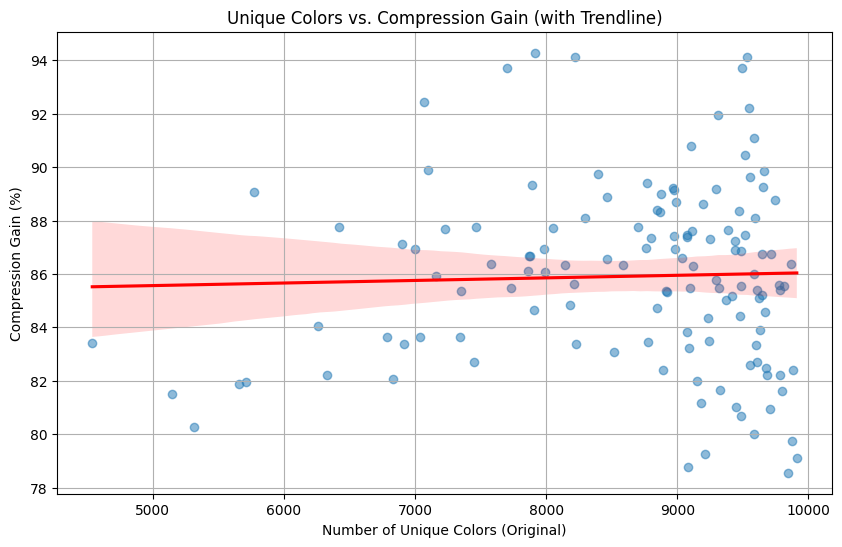

In [19]:
def evaluate_regression(X_feat, y_target, description):
    model = LinearRegression()
    model.fit(X_feat, y_target)
    y_pred = model.predict(X_feat)
    r2 = r2_score(y_target, y_pred)
    print(f"{description} - R2 Score: {r2:.4f}")
    return r2

X = df_compression[['unique_colors']].values
y = df_compression['gain'].values

print("Evaluating various functional forms for Regression:")
evaluate_regression(X, y, "Linear: Gain ~ UniqueColors")
evaluate_regression(X**2, y, "Quadratic: Gain ~ UniqueColors^2")
evaluate_regression(np.log(X), y, "Logarithmic: Gain ~ log(UniqueColors)")
evaluate_regression(1/X, y, "Reciprocal: Gain ~ 1/UniqueColors")

# Exponential: log(y) ~ X  => y ~ exp(X)
# We ensure y > 0 for log transformation
if np.all(y > 0):
    evaluate_regression(X, np.log(y), "Exponential: log(Gain) ~ UniqueColors")

# Power Law: log(y) ~ log(X) => y ~ X^b
if np.all(y > 0):
    evaluate_regression(np.log(X), np.log(y), "Power Law: log(Gain) ~ log(UniqueColors)")

# Final plot of the relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=df_compression, x='unique_colors', y='gain', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Unique Colors vs. Compression Gain (with Trendline)')
plt.xlabel('Number of Unique Colors (Original)')
plt.ylabel('Compression Gain (%)')
plt.grid(True)
plt.show()

Although the reciprocal model is twice as good as the linear one, it still only explains a tiny fraction of the variance. This confirms that the number of unique colors in the original image is not the primary driver of the compression gain when reducing to 5 clusters; other image characteristics likely play a much larger role.

In [20]:
# Save results and backup to Google Drive
df_compression.to_csv('compression_stats.csv', index=False)
!zip -r -q reduced_images.zip reduced_images
!cp compression_stats.csv /content/drive/MyDrive/
!cp reduced_images.zip /content/drive/MyDrive/
print("Task 4 files (CSV and ZIP) saved and copied to Google Drive.")

Task 4 files (CSV and ZIP) saved and copied to Google Drive.


### Task 5: Binary Classification (Kotek vs. Kwiatek)

In this step, we represent each image as a flattened vector of its pixels and train a kNN classifier to distinguish between cats and flowers using both original and compressed data.

In [21]:
def get_image_vector(img_path):
    img = Image.open(img_path).convert('RGB')
    return np.array(img).flatten()

X_orig = []
X_komp = []
y_class = []

for img_path in image_files:
    img_name = os.path.basename(img_path)

    # Target variable: 1 for kotek, 0 for kwiatek
    y_class.append(1 if 'kotek' in img_name else 0)

    # Original vector
    X_orig.append(get_image_vector(img_path))

    # Compressed vector (using path from REDUCED_DIR saved in Task 4)
    red_path = os.path.join(REDUCED_DIR, img_name)
    X_komp.append(get_image_vector(red_path))

X_orig = np.array(X_orig)
X_komp = np.array(X_komp)
y_class = np.array(y_class)

print(f"X_orig shape: {X_orig.shape}")
print(f"X_komp shape: {X_komp.shape}")
print(f"y_class shape: {y_class.shape}")

X_orig shape: (132, 30000)
X_komp shape: (132, 30000)
y_class shape: (132,)


In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report

# Split data (90% train, 10% test) with a fixed seed for consistency
X_orig_train, X_orig_test, y_train, y_test = train_test_split(X_orig, y_class, test_size=0.1, random_state=42, stratify=y_class)
X_komp_train, X_komp_test, _, _ = train_test_split(X_komp, y_class, test_size=0.1, random_state=42, stratify=y_class)

# Hyperparameter tuning for kNN
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}

def train_knn(X_train, y_train):
    knn = KNeighborsClassifier()
    grid = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
    # cv=5: This stands for 5-fold cross-validation. It splits the training data into 5 parts, training the model on 4 and validating on 1, repeating this 5 times for every parameter combination to ensure the results are stable.
    # scoring='f1': This tells the grid search to evaluate the performance of each parameter using the F1-score (the harmonic mean of precision and recall) instead of simple accuracy. This is particularly useful if the classes (cats vs. flowers) were slightly imbalanced.

    grid.fit(X_train, y_train)
    return grid

print("Tuning kNN for Original Data...")
grid_orig = train_knn(X_orig_train, y_train)

print("Tuning kNN for Compressed Data...")
grid_komp = train_knn(X_komp_train, y_train)

print(f"Best k (Orig): {grid_orig.best_params_['n_neighbors']}")
print(f"Best k (Komp): {grid_komp.best_params_['n_neighbors']}")

Tuning kNN for Original Data...
Tuning kNN for Compressed Data...
Best k (Orig): 3
Best k (Komp): 9


In [23]:
def report_f1(grid, X_train, X_test, y_train, y_test, label):
    y_train_pred = grid.predict(X_train)
    y_test_pred = grid.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred)
    f1_val = grid.best_score_
    f1_test = f1_score(y_test, y_test_pred)

    print(f"\n--- {label} Results ---")
    print(f"F1 Train: {f1_train:.4f}")
    print(f"F1 Validation (CV): {f1_val:.4f}")
    print(f"F1 Test: {f1_test:.4f}")

report_f1(grid_orig, X_orig_train, X_orig_test, y_train, y_test, "Original Data")
report_f1(grid_komp, X_komp_train, X_komp_test, y_train, y_test, "Compressed Data")


--- Original Data Results ---
F1 Train: 0.8785
F1 Validation (CV): 0.7710
F1 Test: 0.6250

--- Compressed Data Results ---
F1 Train: 0.8824
F1 Validation (CV): 0.8259
F1 Test: 0.7273


### Task 5: Analysis and Conclusions

In this step, we compare the results of the binary classification performed on both the original and the color-reduced (compressed) images.

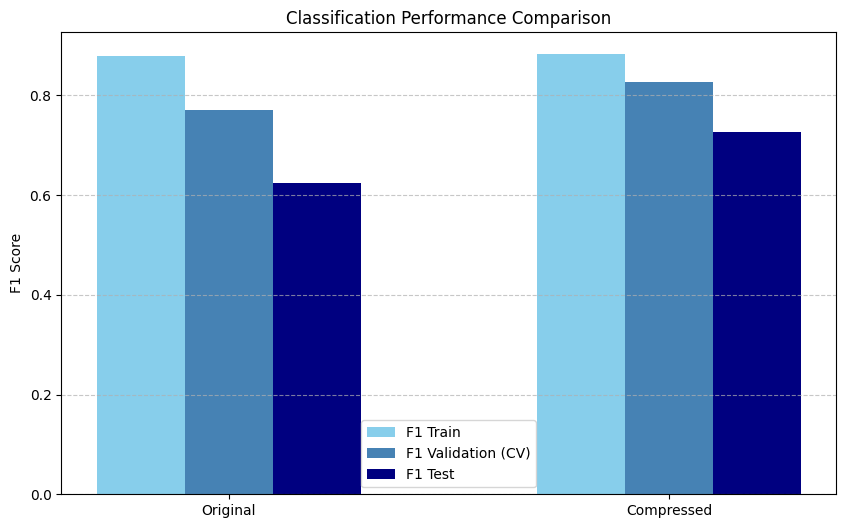

In [24]:
import matplotlib.pyplot as plt

# Data for visualization
labels = ['Original', 'Compressed']
f1_train = [0.8785, 0.8824]
f1_cv = [0.7710, 0.8259]
f1_test = [0.6250, 0.7273]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, f1_train, width, label='F1 Train', color='skyblue')
ax.bar(x, f1_cv, width, label='F1 Validation (CV)', color='steelblue')
ax.bar(x + width, f1_test, width, label='F1 Test', color='navy')

ax.set_ylabel('F1 Score')
ax.set_title('Classification Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Final Commentary:**

Interestingly, the kNN classifier performed **better on the compressed data** (Test F1: 0.7273) compared to the original data (Test F1: 0.6250).

This suggests that color palette reduction via K-Means clustering acted as a form of **feature denoising**. By reducing the thousands of unique colors to just 5 principal colors (centroids), the model likely found it easier to identify the broad structural and color patterns that distinguish cats from flowers, without being distracted by high-frequency color variations or noise present in the original 24-bit images.

While the compression gain was significant (as seen in Task 4), it did not degrade the predictive power for this specific task; rather, it simplified the feature space in a way that benefited the kNN algorithm.

In [25]:
drive.flush_and_unmount()